<a href="https://colab.research.google.com/github/Deepak-212/UAV-Path-Planning/blob/main/Static_Environment_planning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np

class GridEnvironment:
    def __init__(self, shape=(20, 20, 10)):
        self.shape = shape
        self.grid = np.zeros(shape, dtype=int)

    def add_obstacle_block(self, x_range, y_range, z_range):
        self.grid[x_range[0]:x_range[1],
                  y_range[0]:y_range[1],
                  z_range[0]:z_range[1]] = 1

    def is_free(self, x, y, z):
        if 0 <= x < self.shape[0] and \
           0 <= y < self.shape[1] and \
           0 <= z < self.shape[2]:
            return self.grid[x, y, z] == 0
        return False

## Environment Module

In [2]:
env = GridEnvironment(shape=(20, 20, 10))

env.add_obstacle_block((5, 10), (5, 15), (0, 5))
env.add_obstacle_block((12, 17), (2, 8), (2, 7))

BASE     = (0, 0, 1)
TARGETS  = [(18, 18, 4), (15, 3, 6)]

## Path Planning Module

In [3]:
import heapq
import math

def move_cost(cur, nxt):
    dz = nxt[2] - cur[2]
    base = math.sqrt((nxt[0]-cur[0])**2 + (nxt[1]-cur[1])**2 + dz**2)
    return base + max(0, dz) * 0.5

def heuristic(node, goal):
    dx, dy, dz = goal[0]-node[0], goal[1]-node[1], goal[2]-node[2]
    return math.sqrt(dx**2 + dy**2 + dz**2)

def get_neighbors(env, node):
    x, y, z = node
    neighbors = []
    for dx in [-1,0,1]:
        for dy in [-1,0,1]:
            for dz in [-1,0,1]:
                if dx==dy==dz==0: continue
                nx, ny, nz = x+dx, y+dy, z+dz
                if env.is_free(nx, ny, nz):
                    neighbors.append((nx, ny, nz))
    return neighbors

def astar(env, start, goal):
    open_heap = []
    heapq.heappush(open_heap, (0, start))
    came_from = {start: None}
    g_score   = {start: 0.0}
    nodes_expanded = 0

    while open_heap:
        _, current = heapq.heappop(open_heap)
        nodes_expanded += 1
        if current == goal:
            path = []
            while current: path.append(current); current = came_from[current]
            return path[::-1], g_score[goal], nodes_expanded
        for nb in get_neighbors(env, current):
            tg = g_score[current] + move_cost(current, nb)
            if tg < g_score.get(nb, float('inf')):
                g_score[nb] = tg
                came_from[nb] = current
                f = tg + heuristic(nb, goal)
                heapq.heappush(open_heap, (f, nb))
    return [], float('inf'), nodes_expanded

In [4]:
import time

start = BASE
goal  = TARGETS[0]

t0 = time.time()
path, cost, expansions = astar(env, start, goal)
runtime = time.time() - t0

print(f"Path length : {len(path)} steps")
print(f"Energy cost : {cost:.2f} units")
print(f"Nodes expanded: {expansions}")
print(f"Runtime     : {runtime*1000:.2f} ms")

Path length : 19 steps
Energy cost : 29.05 units
Nodes expanded: 772
Runtime     : 49.18 ms


## Single UAV Visualization (Initial)

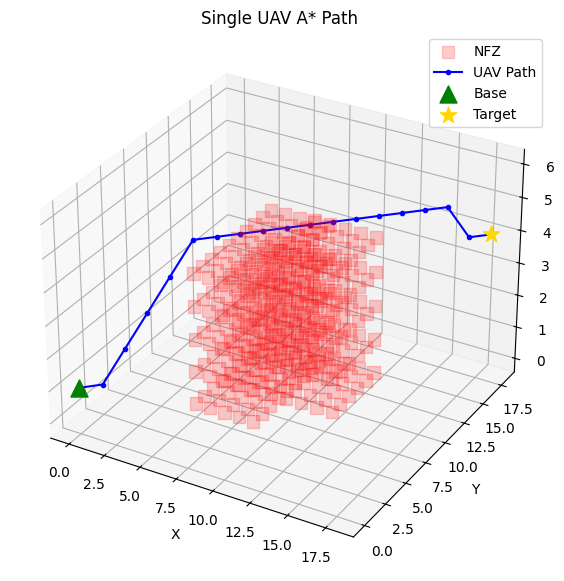

In [5]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection='3d')

obs = np.argwhere(env.grid == 1)
ax.scatter(obs[:,0], obs[:,1], obs[:,2], c='red', marker='s', alpha=0.2, s=80, label='NFZ')

if path:
    px,py,pz = zip(*path)
    ax.plot(px, py, pz, 'b-o', markersize=3, label='UAV Path')

ax.scatter(*BASE,   c='green', s=150, marker='^', label='Base')
ax.scatter(*goal,   c='gold',  s=150, marker='*', label='Target')

ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z (Altitude)')
ax.legend(); plt.title('Single UAV A* Path'); plt.show()

## A* Algorithm Demonstrations and Tests (Integrated)

Single UAV ──────────────────────────
Path length    : 19 steps
Energy cost    : 29.05 units
Nodes expanded : 772
Runtime        : 40.64 ms

Test 1: Wall ────────────────────────
Passed — path length: 0

Test 2: Unreachable Goal ────────────
Passed — empty path returned correctly

Test 3: Round Trip ──────────────────
Passed — 37 steps, total energy: 56.59

Test 4: Multi-Target Mission ────────
Passed — 34 steps, total energy: inf
  (0, 0, 1) → (18, 18, 4) | steps: 19, cost: 29.05, expanded: 772  
  (18, 18, 4) → (15, 3, 6) | steps: 0, cost: inf, expanded: 6454  NO PATH
  (15, 3, 6) → (0, 0, 1) | steps: 16, cost: 19.35, expanded: 356  


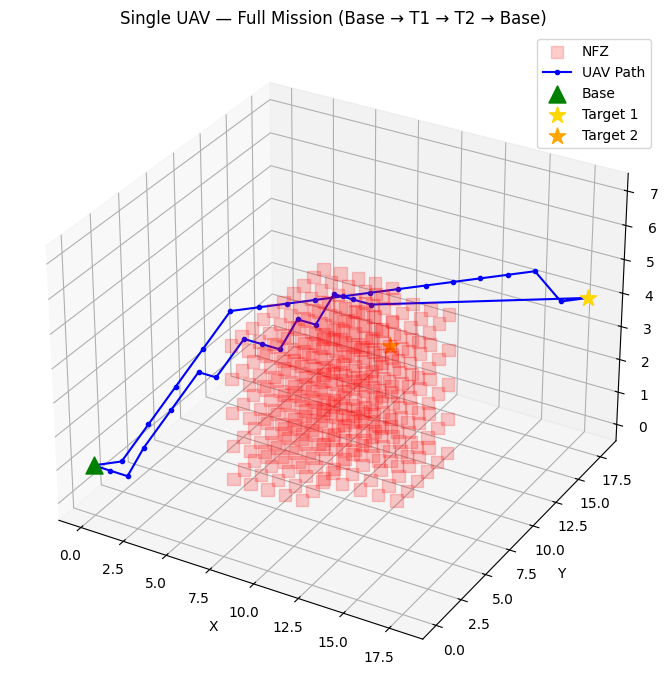

In [6]:
import numpy as np
import heapq
import math
import time
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

class GridEnvironment:
    def __init__(self, shape=(20, 20, 10)):
        self.shape = shape
        self.grid = np.zeros(shape, dtype=int)

    def add_obstacle_block(self, x_range, y_range, z_range):
        self.grid[x_range[0]:x_range[1],
                  y_range[0]:y_range[1],
                  z_range[0]:z_range[1]] = 1

    def is_free(self, x, y, z):
        if 0 <= x < self.shape[0] and \
           0 <= y < self.shape[1] and \
           0 <= z < self.shape[2]:
            return self.grid[x, y, z] == 0
        return False

def move_cost(cur, nxt):
    dz = nxt[2] - cur[2]
    base = math.sqrt((nxt[0]-cur[0])**2 + (nxt[1]-cur[1])**2 + dz**2)
    return base + max(0, dz) * 0.5

def heuristic(node, goal):
    dx, dy, dz = goal[0]-node[0], goal[1]-node[1], goal[2]-node[2]
    return math.sqrt(dx**2 + dy**2 + dz**2)

def get_neighbors(env, node):
    x, y, z = node
    return [(x+dx, y+dy, z+dz)
            for dx in [-1,0,1] for dy in [-1,0,1] for dz in [-1,0,1]
            if not (dx==dy==dz==0) and env.is_free(x+dx, y+dy, z+dz)]

def astar(env, start, goal):
    open_heap = [(0, start)]
    came_from = {start: None}
    g_score   = {start: 0.0}
    nodes_expanded = 0
    while open_heap:
        _, current = heapq.heappop(open_heap)
        nodes_expanded += 1
        if current == goal:
            path = []
            while current:
                path.append(current)
                current = came_from[current]
            return path[::-1], g_score[goal], nodes_expanded
        for nb in get_neighbors(env, current):
            tg = g_score[current] + move_cost(current, nb)
            if tg < g_score.get(nb, float('inf')):
                g_score[nb] = tg
                came_from[nb] = current
                heapq.heappush(open_heap, (tg + heuristic(nb, goal), nb))
    return [], float('inf'), nodes_expanded

env = GridEnvironment(shape=(20, 20, 10))
env.add_obstacle_block((5, 10), (5, 15), (0, 5))
env.add_obstacle_block((12, 17), (2, 8), (2, 7))

BASE    = (0, 0, 1)
TARGETS = [(18, 18, 4), (15, 3, 6)]

t0 = time.time()
path, cost, expansions = astar(env, BASE, TARGETS[0])
runtime = (time.time() - t0) * 1000
print("Single UAV ──────────────────────────")
print(f"Path length    : {len(path)} steps")
print(f"Energy cost    : {cost:.2f} units")
print(f"Nodes expanded : {expansions}")
print(f"Runtime        : {runtime:.2f} ms")

env_wall = GridEnvironment(shape=(20, 20, 10))
env_wall.add_obstacle_block((5, 6), (0, 20), (0, 10))
path_w, _, _ = astar(env_wall, (0, 0, 1), (18, 18, 4))
assert all(p[0] != 5 for p in path_w), "FAIL: Path clipped through wall!"
print("\nTest 1: Wall ────────────────────────")
print(f"Passed — path length: {len(path_w)}")

env_box = GridEnvironment(shape=(20, 20, 10))
env_box.add_obstacle_block((8, 12), (8, 12), (0, 10))
path_b, _, _ = astar(env_box, (0, 0, 1), (10, 10, 5))
assert path_b == [], "FAIL: Should return empty path for enclosed goal!"
print("\nTest 2: Unreachable Goal ────────────")
print("Passed — empty path returned correctly")

path1, c1, _ = astar(env, BASE, TARGETS[0])
path2, c2, _ = astar(env, TARGETS[0], BASE)
full_rt = path1 + path2[1:]
print("\nTest 3: Round Trip ──────────────────")
print(f"Passed — {len(full_rt)} steps, total energy: {c1+c2:.2f}")

waypoints = [BASE, TARGETS[0], TARGETS[1], BASE]
full_path, total_cost = [], 0
for i in range(len(waypoints) - 1):
    seg, cost_seg, _ = astar(env, waypoints[i], waypoints[i+1])
    full_path += seg if i == 0 else seg[1:]
    total_cost += cost_seg
print("\nTest 4: Multi-Target Mission ────────")
print(f"Passed — {len(full_path)} steps, total energy: {total_cost:.2f}")
waypoints = [BASE, TARGETS[0], TARGETS[1], BASE]
for i in range(len(waypoints) - 1):
    seg, seg_cost, exp = astar(env, waypoints[i], waypoints[i+1])
    status = "" if seg else "NO PATH"
    print(f"  {waypoints[i]} → {waypoints[i+1]} | steps: {len(seg)}, cost: {seg_cost:.2f}, expanded: {exp}  {status}")

fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection='3d')

obs = np.argwhere(env.grid == 1)
ax.scatter(obs[:,0], obs[:,1], obs[:,2], c='red', marker='s', alpha=0.2, s=80, label='NFZ')

if full_path:
    px, py, pz = zip(*full_path)
    ax.plot(px, py, pz, 'b-o', markersize=3, label='UAV Path')

ax.scatter(*BASE,      c='green',  s=150, marker='^', label='Base')
ax.scatter(*TARGETS[0], c='gold',  s=150, marker='*', label='Target 1')
ax.scatter(*TARGETS[1], c='orange',s=150, marker='*', label='Target 2')

ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z (Altitude)')
ax.legend()
plt.title('Single UAV — Full Mission (Base → T1 → T2 → Base)')
plt.tight_layout()
plt.show()

Waypoint Validation ─────────────────
BASE (0, 0, 1) is free
TARGET_1 (18, 18, 4) is free
TARGET_2 (15, 3, 8) is free

Single UAV (Base → Target 1) ────────
Path length    : 19 steps
Energy cost    : 29.05 units
Nodes expanded : 772
Runtime        : 29.77 ms

Test 1: Wall ────────────────────────
Passed — path length: 0

Test 2: Unreachable Goal ────────────
Passed — empty path returned correctly

Test 3: Round Trip ──────────────────
Passed — 37 steps, total energy: 56.59

Test 4: Multi-Target Mission ────────
  (0, 0, 1) → (18, 18, 4) | steps: 19, cost: 29.05, expanded: 772  
  (18, 18, 4) → (15, 3, 8) | steps: 16, cost: 19.61, expanded: 680  
  (15, 3, 8) → (0, 0, 1) | steps: 16, cost: 18.85, expanded: 407  
Passed — 49 steps, total energy: 67.51


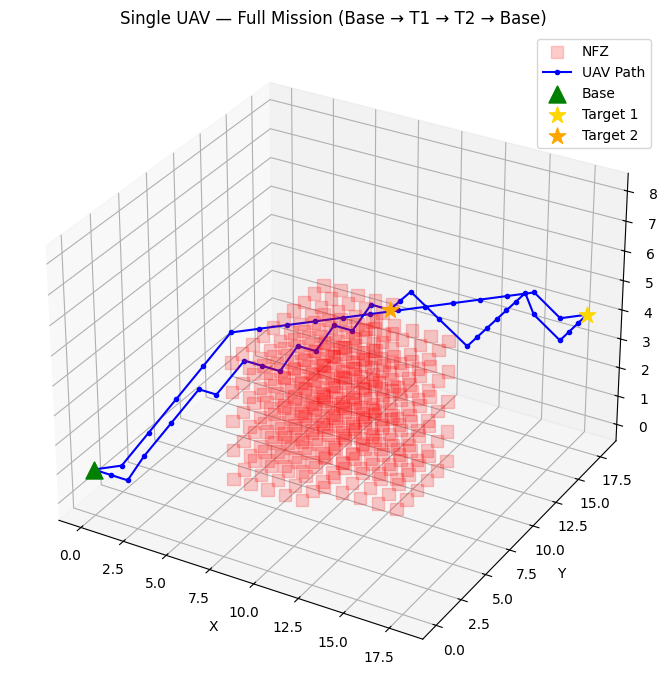

In [7]:
import numpy as np
import heapq
import math
import time
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

class GridEnvironment:
    def __init__(self, shape=(20, 20, 10)):
        self.shape = shape
        self.grid = np.zeros(shape, dtype=int)

    def add_obstacle_block(self, x_range, y_range, z_range):
        self.grid[x_range[0]:x_range[1],
                  y_range[0]:y_range[1],
                  z_range[0]:z_range[1]] = 1

    def is_free(self, x, y, z):
        if 0 <= x < self.shape[0] and \
           0 <= y < self.shape[1] and \
           0 <= z < self.shape[2]:
            return self.grid[x, y, z] == 0
        return False

def move_cost(cur, nxt):
    dz = nxt[2] - cur[2]
    base = math.sqrt((nxt[0]-cur[0])**2 + (nxt[1]-cur[1])**2 + dz**2)
    return base + max(0, dz) * 0.5

def heuristic(node, goal):
    dx, dy, dz = goal[0]-node[0], goal[1]-node[1], goal[2]-node[2]
    return math.sqrt(dx**2 + dy**2 + dz**2)

def get_neighbors(env, node):
    x, y, z = node
    return [(x+dx, y+dy, z+dz)
            for dx in [-1,0,1] for dy in [-1,0,1] for dz in [-1,0,1]
            if not (dx==dy==dz==0) and env.is_free(x+dx, y+dy, z+dz)]

def astar(env, start, goal):
    open_heap = [(0, start)]
    came_from = {start: None}
    g_score   = {start: 0.0}
    nodes_expanded = 0
    while open_heap:
        _, current = heapq.heappop(open_heap)
        nodes_expanded += 1
        if current == goal:
            path = []
            while current:
                path.append(current)
                current = came_from[current]
            return path[::-1], g_score[goal], nodes_expanded
        for nb in get_neighbors(env, current):
            tg = g_score[current] + move_cost(current, nb)
            if tg < g_score.get(nb, float('inf')):
                g_score[nb] = tg
                came_from[nb] = current
                heapq.heappush(open_heap, (tg + heuristic(nb, goal), nb))
    return [], float('inf'), nodes_expanded

env = GridEnvironment(shape=(20, 20, 10))
env.add_obstacle_block((5, 10), (5, 15), (0, 5))
env.add_obstacle_block((12, 17), (2, 8), (2, 7))

BASE    = (0, 0, 1)
TARGETS = [(18, 18, 4), (15, 3, 8)]

print("Waypoint Validation ─────────────────")
for label, pt in [("BASE", BASE), ("TARGET_1", TARGETS[0]), ("TARGET_2", TARGETS[1])]:
    assert env.is_free(*pt), f"{label} at {pt} is inside an obstacle!"
    print(f"{label} {pt} is free")

t0 = time.time()
path, cost, expansions = astar(env, BASE, TARGETS[0])
runtime = (time.time() - t0) * 1000
print("\nSingle UAV (Base → Target 1) ────────")
print(f"Path length    : {len(path)} steps")
print(f"Energy cost    : {cost:.2f} units")
print(f"Nodes expanded : {expansions}")
print(f"Runtime        : {runtime:.2f} ms")

env_wall = GridEnvironment(shape=(20, 20, 10))
env_wall.add_obstacle_block((5, 6), (0, 20), (0, 10))
path_w, _, _ = astar(env_wall, (0, 0, 1), (18, 18, 4))
assert all(p[0] != 5 for p in path_w), "FAIL: Path clipped through wall!"
print("\nTest 1: Wall ────────────────────────")
print(f"Passed — path length: {len(path_w)}")

env_box = GridEnvironment(shape=(20, 20, 10))
env_box.add_obstacle_block((8, 12), (8, 12), (0, 10))
path_b, _, _ = astar(env_box, (0, 0, 1), (10, 10, 5))
assert path_b == [], "FAIL: Should return empty path for enclosed goal!"
print("\nTest 2: Unreachable Goal ────────────")
print("Passed — empty path returned correctly")

path1, c1, _ = astar(env, BASE, TARGETS[0])
path2, c2, _ = astar(env, TARGETS[0], BASE)
full_rt = path1 + path2[1:]
print("\nTest 3: Round Trip ──────────────────")
print(f"Passed — {len(full_rt)} steps, total energy: {c1+c2:.2f}")

waypoints = [BASE, TARGETS[0], TARGETS[1], BASE]
full_path, total_cost = [], 0
all_ok = True
print("\nTest 4: Multi-Target Mission ────────")
for i in range(len(waypoints) - 1):
    seg, seg_cost, exp = astar(env, waypoints[i], waypoints[i+1])
    status = "" if seg else "NO PATH"
    if not seg: all_ok = False
    print(f"  {waypoints[i]} → {waypoints[i+1]} | steps: {len(seg)}, cost: {seg_cost:.2f}, expanded: {exp}  {status}")
    full_path += seg if i == 0 else seg[1:]
    total_cost += seg_cost
if all_ok:
    print(f"Passed — {len(full_path)} steps, total energy: {total_cost:.2f}")
else:
    print("Mission incomplete — fix blocked segments above")

fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection='3d')

ob = np.argwhere(env.grid == 1)
ax.scatter(ob[:,0], ob[:,1], ob[:,2], c='red', marker='s', alpha=0.2, s=80, label='NFZ')

if full_path:
    px, py, pz = zip(*full_path)
    ax.plot(px, py, pz, 'b-o', markersize=3, label='UAV Path')

ax.scatter(*BASE,       c='green',  s=150, marker='^', label='Base')
ax.scatter(*TARGETS[0], c='gold',   s=150, marker='*', label='Target 1')
ax.scatter(*TARGETS[1], c='orange', s=150, marker='*', label='Target 2')

ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z (Altitude)')
ax.legend()
plt.title('Single UAV — Full Mission (Base → T1 → T2 → Base)')
plt.tight_layout()
plt.show()

## Multi-UAV Coordination Module (CSP)

Waypoint Validation ─────────────────
  BASE (0, 0, 1) is free
  T1 (18, 18, 4) is free
  T2 (15, 3, 8) is free
  T3 (3, 18, 6) is free

Multi-UAV Path Planning ─────────────
  UAV_1 | steps:  37 | energy:  56.59 / 80.0 | nodes:  1378 | Feasible
  UAV_2 | steps:  31 | energy:  41.21 / 80.0 | nodes:  1253 | Feasible
  UAV_3 | steps:  37 | energy:  44.55 / 80.0 | nodes:  1280 | Feasible

Spatial Path Overlap ────────────────
  UAV_1 vs UAV_2: 1 shared cells  e.g. [(0, 0, 1)]
  UAV_1 vs UAV_3: 1 shared cells  e.g. [(0, 0, 1)]
  UAV_2 vs UAV_3: 1 shared cells  e.g. [(0, 0, 1)]

Pre-CSP Conflict Detection ──────────
  UAV_1 vs UAV_2: 2 conflicts
  UAV_1 vs UAV_3: 5 conflicts
  UAV_2 vs UAV_3: 2 conflicts
  Total conflicts before CSP: 9


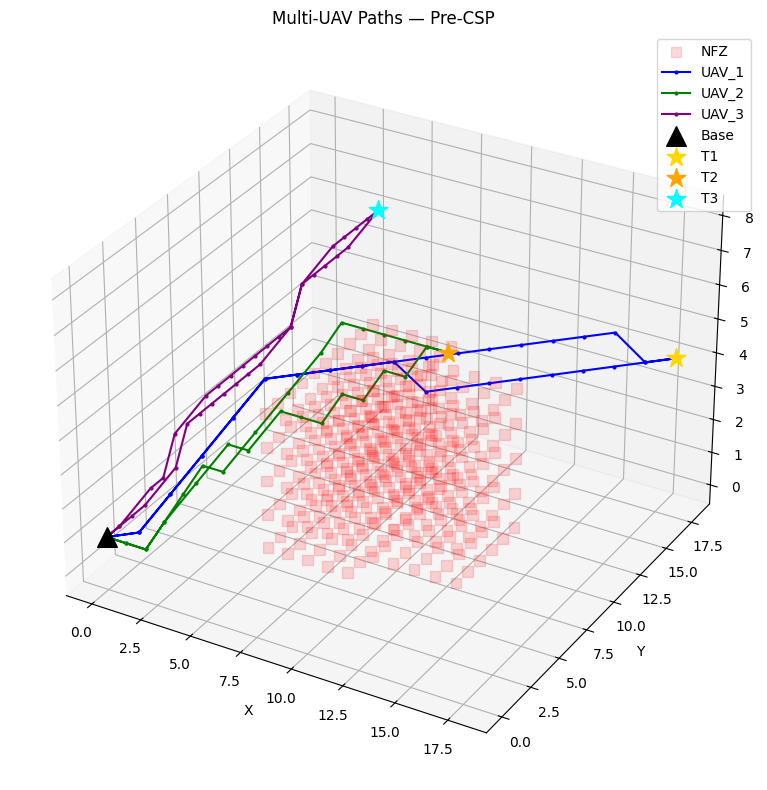

In [8]:
BATTERY_CAPACITY = 80.0
D_SAFE           = 2.0

TARGETS = [(18, 18, 4), (15, 3, 8), (3, 18, 6)]
HOVER_POS = BASE

print("Waypoint Validation ─────────────────")
for label, pt in [("BASE", BASE), ("T1", TARGETS[0]), ("T2", TARGETS[1]), ("T3", TARGETS[2])]:
    assert env.is_free(*pt), f"{label} at {pt} is inside an obstacle!"
    print(f"  {label} {pt} is free")

uav_missions = {
    "UAV_1": [BASE, TARGETS[0], BASE],
    "UAV_2": [BASE, TARGETS[1], BASE],
    "UAV_3": [BASE, TARGETS[2], BASE],
}

uav_paths      = {}
uav_costs      = {}
uav_expansions = {}
uav_feasible   = {}

print("\nMulti-UAV Path Planning ─────────────")
for uav_id, waypoints in uav_missions.items():
    full_path, total_cost, total_exp = [], 0, 0
    ok = True
    for i in range(len(waypoints) - 1):
        seg, seg_cost, exp = astar(env, waypoints[i], waypoints[i+1])
        if not seg:
            print(f"  {uav_id}: No path {waypoints[i]} → {waypoints[i+1]}")
            ok = False; break
        full_path += seg if i == 0 else seg[1:]
        total_cost += seg_cost
        total_exp  += exp
    feasible = ok and (total_cost <= BATTERY_CAPACITY)
    uav_paths[uav_id]      = full_path if ok else []
    uav_costs[uav_id]      = total_cost if ok else float('inf')
    uav_expansions[uav_id] = total_exp
    uav_feasible[uav_id]   = feasible
    status = "Feasible" if feasible else ("Battery exceeded" if ok else "No path")
    print(f"  {uav_id} | steps: {len(full_path):3d} | energy: {total_cost:6.2f} / {BATTERY_CAPACITY} | nodes: {total_exp:5d} | {status}")

print("\nSpatial Path Overlap ────────────────")
uav_ids = list(uav_paths.keys())
for i in range(len(uav_ids)):
    for j in range(i+1, len(uav_ids)):
        id_a, id_b = uav_ids[i], uav_ids[j]
        overlap = set(uav_paths[id_a]) & set(uav_paths[id_b])
        print(f"  {id_a} vs {id_b}: {len(overlap)} shared cells", end="")
        print(f"  e.g. {list(overlap)[:3]}" if overlap else "  No overlap")

def is_airborne(path, offset, t):
    local_t = t - offset
    return 0 <= local_t < len(path)

def get_pos_at_t(path, offset, t):
    local_t = t - offset
    if local_t < 0:              return HOVER_POS
    if local_t >= len(path):     return None
    return path[local_t]

def check_pair(path_a, off_a, path_b, off_b, d_safe):
    t_max = max(len(path_a) + off_a, len(path_b) + off_b)
    conflicts = []
    for t in range(t_max):
        both_waiting = (t < off_a) and (t < off_b)
        if both_waiting: continue
        pa = get_pos_at_t(path_a, off_a, t)
        pb = get_pos_at_t(path_b, off_b, t)
        if pa is None or pb is None: continue
        dist = math.sqrt((pa[0]-pb[0])**2 + (pa[1]-pb[1])**2 + (pa[2]-pb[2])**2)
        if dist < d_safe:
            conflicts.append((t, pa, pb, dist))
    return conflicts

pre_conflicts = 0
print("\nPre-CSP Conflict Detection ──────────")
for i in range(len(uav_ids)):
    for j in range(i+1, len(uav_ids)):
        id_a, id_b = uav_ids[i], uav_ids[j]
        c = check_pair(uav_paths[id_a], 0, uav_paths[id_b], 0, D_SAFE)
        pre_conflicts += len(c)
        print(f"  {id_a} vs {id_b}: {len(c)} conflicts")
print(f"  Total conflicts before CSP: {pre_conflicts}")

colors = {"UAV_1": "blue", "UAV_2": "green", "UAV_3": "purple"}
fig = plt.figure(figsize=(12, 8))
ax  = fig.add_subplot(111, projection='3d')
obs = np.argwhere(env.grid == 1)
ax.scatter(obs[:,0], obs[:,1], obs[:,2], c='red', marker='s', alpha=0.15, s=60, label='NFZ')
for uav_id, path in uav_paths.items():
    if path:
        px, py, pz = zip(*path)
        ax.plot(px, py, pz, '-o', color=colors[uav_id], markersize=2, label=uav_id)
ax.scatter(*BASE,       c='black',  s=200, marker='^', zorder=5, label='Base')
ax.scatter(*TARGETS[0], c='gold',   s=200, marker='*', zorder=5, label='T1')
ax.scatter(*TARGETS[1], c='orange', s=200, marker='*', zorder=5, label='T2')
ax.scatter(*TARGETS[2], c='cyan',   s=200, marker='*', zorder=5, label='T3')
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.legend(); plt.title('Multi-UAV Paths — Pre-CSP'); plt.tight_layout(); plt.show()

In [9]:
MAX_OFFSET = 100

def backtrack_csp(uav_ids, paths, domain, d_safe, assignment={}):
    if len(assignment) == len(uav_ids):
        return assignment
    uav = next(u for u in uav_ids if u not in assignment)
    for offset in domain:
        valid = True
        for assigned_uav, assigned_offset in assignment.items():
            if check_pair(paths[uav], offset,
                          paths[assigned_uav], assigned_offset, d_safe):
                valid = False
                break
        if valid:
            result = backtrack_csp(uav_ids, paths, domain, d_safe,
                                   {**assignment, uav: offset})
            if result is not None:
                return result
    return None

domain = list(range(0, MAX_OFFSET + 1))

print("CSP Solver ──────────────────────────")
print(f"  Variables : {uav_ids}")
print(f"  Domain    : offsets 0–{MAX_OFFSET} timesteps")
print(f"  D_safe    : {D_SAFE} grid units\n")

t0 = time.time()
solution = backtrack_csp(uav_ids, uav_paths, domain, D_SAFE, {})
csp_runtime = (time.time() - t0) * 1000

if solution:
    print(f"Solution found in {csp_runtime:.2f} ms")
    for uav_id, offset in solution.items():
        print(f"  {uav_id} departs at t={offset}")
else:
    print(f"No solution — increase MAX_OFFSET beyond {MAX_OFFSET}")

if solution:
    print("\nPost-CSP Conflict Check ─────────────")
    total_remaining = 0
    for i in range(len(uav_ids)):
        for j in range(i+1, len(uav_ids)):
            id_a, id_b = uav_ids[i], uav_ids[j]
            c = check_pair(uav_paths[id_a], solution[id_a],
                           uav_paths[id_b], solution[id_b], D_SAFE)
            total_remaining += len(c)
            print(f"  {id_a} vs {id_b}: {len(c)} conflicts remaining")
    if total_remaining == 0:
        print("All conflicts resolved — safe separation maintained")
    else:
        print(f"{total_remaining} conflicts remain")

    print("\nFinal Mission Metrics ───────────────")
    print(f"  {'UAV':<8} {'Steps':>6} {'Energy':>8} {'Nodes':>8} {'Departs':>9} {'Feasible':>10}")
    print(f"  {'─'*8} {'─'*6} {'─'*8} {'─'*8} {'─'*9} {'─'*10}")
    for uav_id in uav_ids:
        print(f"  {uav_id:<8} {len(uav_paths[uav_id]):>6} "
              f"{uav_costs[uav_id]:>8.2f} "
              f"{uav_expansions[uav_id]:>8} "
              f"{'t='+str(solution[uav_id]):>9} "
              f"{'Yes' if uav_feasible[uav_id] else 'No':>10}")
    print(f"\n  Conflicts before CSP : {pre_conflicts}")
    print(f"  Conflicts after CSP  : {total_remaining}")
    print(f"  CSP runtime          : {csp_runtime:.2f} ms")

    colors = {"UAV_1": "blue", "UAV_2": "green", "UAV_3": "purple"}
    fig = plt.figure(figsize=(12, 8))
    ax  = fig.add_subplot(111, projection='3d')
    obs = np.argwhere(env.grid == 1)
    ax.scatter(obs[:,0], obs[:,1], obs[:,2], c='red', marker='s', alpha=0.15, s=60, label='NFZ')
    for uav_id, path in uav_paths.items():
        if not path: continue
        offset = solution[uav_id]
        display_path = [HOVER_POS] * offset + path
        px, py, pz = zip(*display_path)
        ax.plot(px, py, pz, '-o', color=colors[uav_id],
                markersize=2, label=f"{uav_id} (t={offset})")
    ax.scatter(*BASE,       c='black',  s=200, marker='^', zorder=5, label='Base')
    ax.scatter(*TARGETS[0], c='gold',   s=200, marker='*', zorder=5, label='T1')
    ax.scatter(*TARGETS[1], c='orange', s=200, marker='*', zorder=5, label='T2')
    ax.scatter(*TARGETS[2], c='cyan',   s=200, marker='*', zorder=5, label='T3')
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.legend()
    plt.title('Multi-UAV Paths — Post-CSP (Staggered Departures)')
    plt.tight_layout()
    plt.show()

CSP Solver ──────────────────────────
  Variables : ['UAV_1', 'UAV_2', 'UAV_3']
  Domain    : offsets 0–100 timesteps
  D_safe    : 2.0 grid units

No solution — increase MAX_OFFSET beyond 100


In [10]:
print("Deep Pairwise Diagnosis ─────────────")
pairs = [("UAV_1", "UAV_2"), ("UAV_1", "UAV_3"), ("UAV_2", "UAV_3")]

for id_a, id_b in pairs:
    found = None
    min_conflicts = float('inf')
    best_offsets  = (0, 0)
    for off_a in range(0, 50):
        for off_b in range(0, 50):
            c = check_pair(uav_paths[id_a], off_a, uav_paths[id_b], off_b, D_SAFE)
            if len(c) < min_conflicts:
                min_conflicts = len(c)
                best_offsets  = (off_a, off_b)
            if not c:
                found = (off_a, off_b)
                break
        if found: break
    if found:
        print(f"  {id_a} vs {id_b}: solvable at offsets {found}")
    else:
        print(f"  {id_a} vs {id_b}: UNSOLVABLE — best was {min_conflicts} conflicts at offsets {best_offsets}")

print("\nConflict Cell Inspection ────────────")
for id_a, id_b in pairs:
    c = check_pair(uav_paths[id_a], 0, uav_paths[id_b], 0, D_SAFE)
    shared = set(uav_paths[id_a]) & set(uav_paths[id_b])
    print(f"\n  {id_a} vs {id_b}:")
    print(f"    Shared grid cells : {len(shared)}  → {list(shared)[:6]}")
    print(f"    Conflicts at t=0  : {len(c)}")
    print(f"    {id_a} path start/end: {uav_paths[id_a][:3]} ... {uav_paths[id_a][-3:]}")
    print(f"    {id_b} path start/end: {uav_paths[id_b][:3]} ... {uav_paths[id_b][-3:]}")

print("\nFull Paths ──────────────────────────")
for uav_id in uav_ids:
    print(f"  {uav_id}: {uav_paths[uav_id]}")

Deep Pairwise Diagnosis ─────────────
  UAV_1 vs UAV_2: UNSOLVABLE — best was 2 conflicts at offsets (0, 0)
  UAV_1 vs UAV_3: UNSOLVABLE — best was 2 conflicts at offsets (0, 2)
  UAV_2 vs UAV_3: UNSOLVABLE — best was 2 conflicts at offsets (0, 0)

Conflict Cell Inspection ────────────

  UAV_1 vs UAV_2:
    Shared grid cells : 1  → [(0, 0, 1)]
    Conflicts at t=0  : 2
    UAV_1 path start/end: [(0, 0, 1), (1, 1, 1), (2, 2, 2)] ... [(2, 2, 2), (1, 1, 1), (0, 0, 1)]
    UAV_2 path start/end: [(0, 0, 1), (1, 0, 1), (2, 0, 1)] ... [(2, 0, 1), (1, 0, 1), (0, 0, 1)]

  UAV_1 vs UAV_3:
    Shared grid cells : 1  → [(0, 0, 1)]
    Conflicts at t=0  : 5
    UAV_1 path start/end: [(0, 0, 1), (1, 1, 1), (2, 2, 2)] ... [(2, 2, 2), (1, 1, 1), (0, 0, 1)]
    UAV_3 path start/end: [(0, 0, 1), (0, 1, 1), (0, 2, 1)] ... [(1, 2, 2), (0, 1, 1), (0, 0, 1)]

  UAV_2 vs UAV_3:
    Shared grid cells : 1  → [(0, 0, 1)]
    Conflicts at t=0  : 2
    UAV_2 path start/end: [(0, 0, 1), (1, 0, 1), (2, 0, 1)] ...

Pairwise Check (BASE excluded) ──────
  UAV_1 vs UAV_2: 1 conflicts
  UAV_1 vs UAV_3: 3 conflicts
  UAV_2 vs UAV_3: 1 conflicts
  Total before CSP: 5

CSP Solver ──────────────────────────
Solution found in 0.25 ms
  UAV_1 departs at t=0
  UAV_2 departs at t=1
  UAV_3 departs at t=2

Post-CSP Conflict Check ─────────────
  UAV_1 vs UAV_2: 0 conflicts remaining
  UAV_1 vs UAV_3: 0 conflicts remaining
  UAV_2 vs UAV_3: 0 conflicts remaining
  All conflicts resolved

Final Mission Metrics ───────────────
  UAV       Steps   Energy    Nodes   Departs   Feasible
  ──────── ────── ──────── ──────── ───────── ──────────
  UAV_1        37    56.59     1378       t=0        Yes
  UAV_2        31    41.21     1253       t=1        Yes
  UAV_3        37    44.55     1280       t=2        Yes

  Conflicts before CSP : 5
  Conflicts after  CSP : 0
  CSP runtime          : 0.25 ms


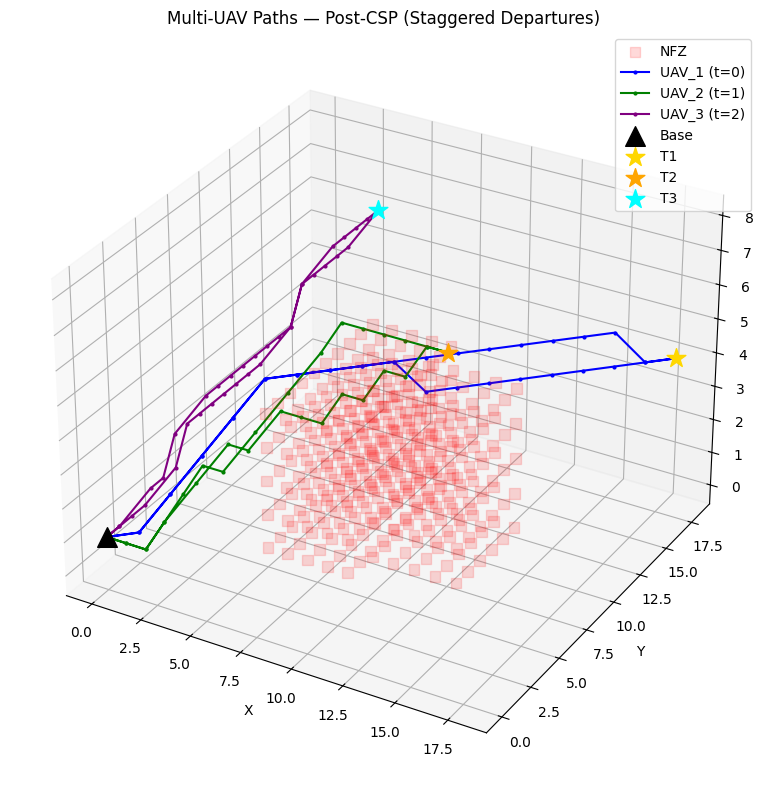

In [11]:
def check_pair(path_a, off_a, path_b, off_b, d_safe):
    t_max = max(len(path_a) + off_a, len(path_b) + off_b)
    conflicts = []
    for t in range(t_max):
        both_waiting = (t < off_a) and (t < off_b)
        if both_waiting: continue
        pa = get_pos_at_t(path_a, off_a, t)
        pb = get_pos_at_t(path_b, off_b, t)
        if pa is None or pb is None: continue

        if pa == BASE or pb == BASE: continue

        dist = math.sqrt((pa[0]-pb[0])**2 + (pa[1]-pb[1])**2 + (pa[2]-pb[2])**2)
        if dist < d_safe:
            conflicts.append((t, pa, pb, dist))
    return conflicts

print("Pairwise Check (BASE excluded) ──────")
pre_conflicts = 0
for i in range(len(uav_ids)):
    for j in range(i+1, len(uav_ids)):
        id_a, id_b = uav_ids[i], uav_ids[j]
        c = check_pair(uav_paths[id_a], 0, uav_paths[id_b], 0, D_SAFE)
        pre_conflicts += len(c)
        print(f"  {id_a} vs {id_b}: {len(c)} conflicts")
print(f"  Total before CSP: {pre_conflicts}")

MAX_OFFSET = 30
domain     = list(range(0, MAX_OFFSET + 1))

print("\nCSP Solver ──────────────────────────")
t0       = time.time()
solution = backtrack_csp(uav_ids, uav_paths, domain, D_SAFE, {})
csp_runtime = (time.time() - t0) * 1000

if solution:
    print(f"Solution found in {csp_runtime:.2f} ms")
    for uav_id, offset in solution.items():
        print(f"  {uav_id} departs at t={offset}")
else:
    print(f"No solution within offset 0–{MAX_OFFSET}")

if solution:
    print("\nPost-CSP Conflict Check ─────────────")
    total_remaining = 0
    for i in range(len(uav_ids)):
        for j in range(i+1, len(uav_ids)):
            id_a, id_b = uav_ids[i], uav_ids[j]
            c = check_pair(uav_paths[id_a], solution[id_a],
                           uav_paths[id_b], solution[id_b], D_SAFE)
            total_remaining += len(c)
            print(f"  {id_a} vs {id_b}: {len(c)} conflicts remaining")
    status = "All conflicts resolved" if total_remaining == 0 else f"{total_remaining} remain"
    print(f"  {status}")

    print("\nFinal Mission Metrics ───────────────")
    print(f"  {'UAV':<8} {'Steps':>6} {'Energy':>8} {'Nodes':>8} {'Departs':>9} {'Feasible':>10}")
    print(f"  {'─'*8} {'─'*6} {'─'*8} {'─'*8} {'─'*9} {'─'*10}")
    for uav_id in uav_ids:
        print(f"  {uav_id:<8} {len(uav_paths[uav_id]):>6} "
              f"{uav_costs[uav_id]:>8.2f} "
              f"{uav_expansions[uav_id]:>8} "
              f"{'t='+str(solution[uav_id]):>9} "
              f"{'Yes' if uav_feasible[uav_id] else 'No':>10}")
    print(f"\n  Conflicts before CSP : {pre_conflicts}")
    print(f"  Conflicts after  CSP : {total_remaining}")
    print(f"  CSP runtime          : {csp_runtime:.2f} ms")

    colors = {"UAV_1": "blue", "UAV_2": "green", "UAV_3": "purple"}
    fig = plt.figure(figsize=(12, 8))
    ax  = fig.add_subplot(111, projection='3d')
    obs = np.argwhere(env.grid == 1)
    ax.scatter(obs[:,0], obs[:,1], obs[:,2],
               c='red', marker='s', alpha=0.15, s=60, label='NFZ')
    for uav_id, path in uav_paths.items():
        if not path: continue
        offset = solution[uav_id]
        display_path = [HOVER_POS] * offset + path
        px, py, pz = zip(*display_path)
        ax.plot(px, py, pz, '-o', color=colors[uav_id],
                markersize=2, label=f"{uav_id} (t={offset})")
    ax.scatter(*BASE,       c='black',  s=200, marker='^', zorder=5, label='Base')
    ax.scatter(*TARGETS[0], c='gold',   s=200, marker='*', zorder=5, label='T1')
    ax.scatter(*TARGETS[1], c='orange', s=200, marker='*', zorder=5, label='T2')
    ax.scatter(*TARGETS[2], c='cyan',   s=200, marker='*', zorder=5, label='T3')
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.legend()
    plt.title('Multi-UAV Paths — Post-CSP (Staggered Departures)')
    plt.tight_layout()
    plt.show()